# Limitations

## Hallucination

In [ ]:
# Techniques for handling Hallucination:
    # 1) Prompt Fine Tuning -> Focus on the given instructions only, etc.
    
    # 2) Chain of Thought
    
    # 3) Modify Some Parameters
            # Temperature :: It is a parameter of Creativity. 
                # It is generally in b/w 0 and 1.
                # 0 - less creativity & less hallucination (lower list of probable words)
                # 1 - more creativity & high hallucination (higher list of probable words)
                
            # Top-K :: Number of words/tokens
                # Based on the temperature, the LLM creates a list of probable words. And, top-k limits the no. of those words.
                # For example, cat is sitting on a ------------. To complete this sentence, it may create a 100 list of probable words.
                # How big/small this list can be will depend upon temperature.
                # When we say top-k = 3, it will pick the first 3 words with the highest probability.
                # The problem with this param is it may choose low probability words as well based on the given value.
                # For example, top-k = 10 means it will pick 10 words and may include unlikely words.
                
            ## low temperature and top-k together reduces hallucination.
            
            # Top-P :: Probability
                # We don't tell the model how many words it has to pick. We are just telling the probability.
                # Keep on picking the word until the sum of probability of the words is 0.95 (for example).
                
            ## We don't use temperature and top-p together. If we do, it may limit the model thinking capabilities.

            # Max Tokens :: Output Tokens
                # We can limit the model's response with this param.
                # For example, when we ask 'What is GenAI?' 
                # The model can respond in creative way if max-tokens are 1000 compared to 100 (limited response).
                # Reducing the tokens may reduce the creativity and it may lead to less hallucination.
                
            # Total Tokens = Input Tokens (Prompt + any input data you are feeding) + Completion Tokens
            
    # 4) Self-Consistency
            # We ask the model to solve a complex problem in 'n' number of approaches and pick the consistent answer from them.
            # This may reduce hallucination
            # For example, a complex problem is solved in 5 different ways. The answers are 10, 10, 10.2, 9.5, 11. It will pick 10.


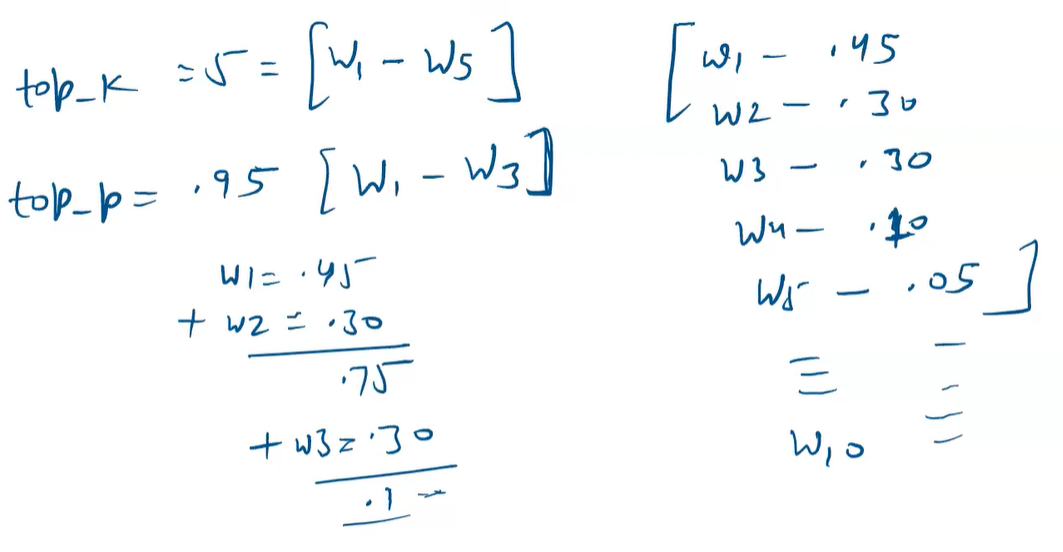

# Prompting Techniques

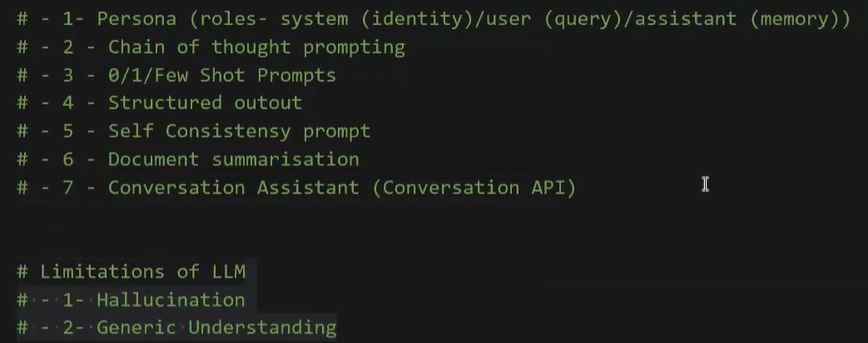

In [2]:
import numpy as np
import pandas as pd
import os
from openai import OpenAI
from dotenv import load_dotenv

In [3]:
load_dotenv()

True

In [4]:
openai_api_key = os.getenv('OPENAI_SECRET_KEY')

In [5]:
client = OpenAI(api_key=openai_api_key)

## 0 Shot Prompting

In [6]:
# We just give the query but we do not provide any example to guide the LLM format its answer

## 1 Shot Prompting

In [ ]:
# We give the query and provide an example to guide the LLM format its answer

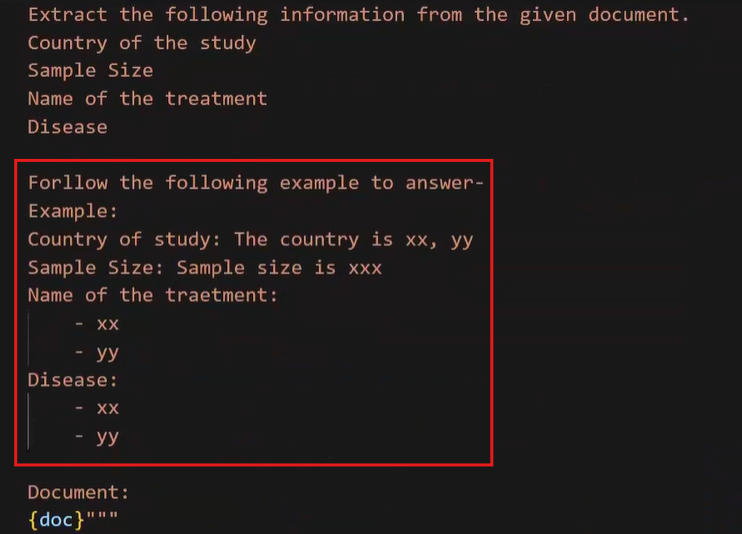

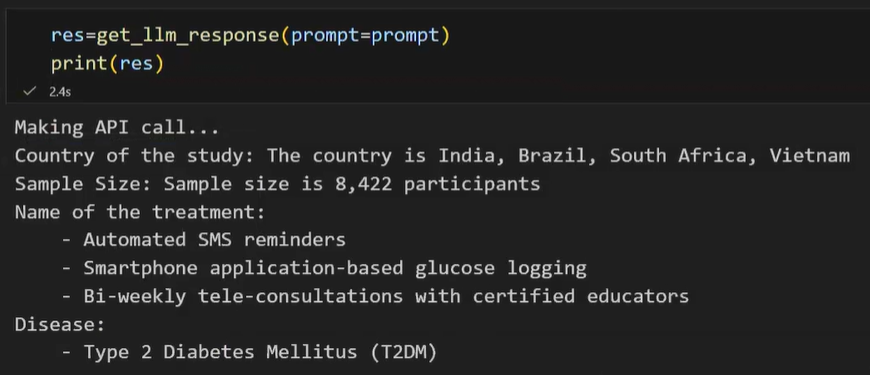

## Few Shot Prompting

In [ ]:
# We give the query and provide few examples to guide the LLM format its answer

## Self Consistency Prompting

In [8]:
# We ask the LLM to answer the same problem in different ways.
# We ask it to cross-check all the outputs and finalize the most consistent answer.

In [9]:
prompt='''Using self consistency, answer the following question in different ways.
Also, provide chain of thought reasoning for your response.

Question:
There are two brothers Tom and Jerry.
When Jerry was 4 years old, Tom was twice of his age.
Today, Jerry is 15 years old so what will be the age of Tom?
'''

In [10]:
response = client.chat.completions.create(
    model='gpt-4o-mini',
    messages=[{'role': 'user', 'content': prompt}],
    n=3
)

print(response.choices[0].message.content)

To solve the problem, we need to determine Tom's age given the relationship between his age and Jerry's during a specific time in the past. Let's break down the information provided in the question using different reasoning approaches while ensuring self-consistency.

### Method 1: Simple Age Calculation
1. When Jerry was 4, Tom was twice his age. Therefore, Tom's age at that time was:
   - Jerry's age = 4 years
   - Tom's age = 2 × 4 = 8 years
2. The age difference between Tom and Jerry is:
   - Difference = Tom's age - Jerry's age = 8 - 4 = 4 years
3. Today, Jerry is 15 years old. Since the age difference remains constant, Tom's age today is:
   - Tom's age = Jerry's current age + age difference = 15 + 4 = 19 years

### Method 2: Timeline Representation
1. Let's establish a timeline:
   - When Jerry was 4: Jerry = 4, Tom = 8
   - Age difference established: Tom is older by 4 years.
2. Progress to today's ages:
   - Jerry's current age is 15.
   - Calculate Tom’s current age: = Jerry'